# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Samuel Bromberg

**Date:** 9 September 2026

In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
data = pd.read_csv('ForeignGifts_edu.csv')

Saving ForeignGifts_edu.csv to ForeignGifts_edu (1).csv


In [2]:
# Q1 Written on paper photos found in Github Repo

Dataset shape: (28221, 10)

First few rows:
   ID   OPEID               Institution Name          City State  \
0   1  102000  Jacksonville State University  Jacksonville    AL   
1   2  104700                Troy University          Troy    AL   
2   3  105100          University of Alabama    Tuscaloosa    AL   
3   4  105100          University of Alabama    Tuscaloosa    AL   
4   5  105100          University of Alabama    Tuscaloosa    AL   

   Foreign Gift Received Date  Foreign Gift Amount      Gift Type  \
0                       43738               250000  Monetary Gift   
1                       43592               463657       Contract   
2                       43466              3649107       Contract   
3                       43472                 1000       Contract   
4                       43479                49476       Contract   

  Country of Giftor                          Giftor Name  
0             CHINA                                  NaN  
1             

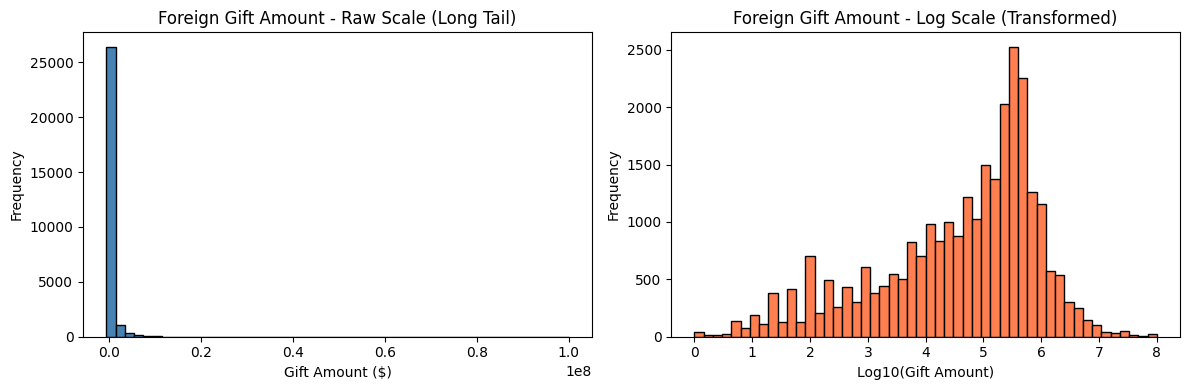

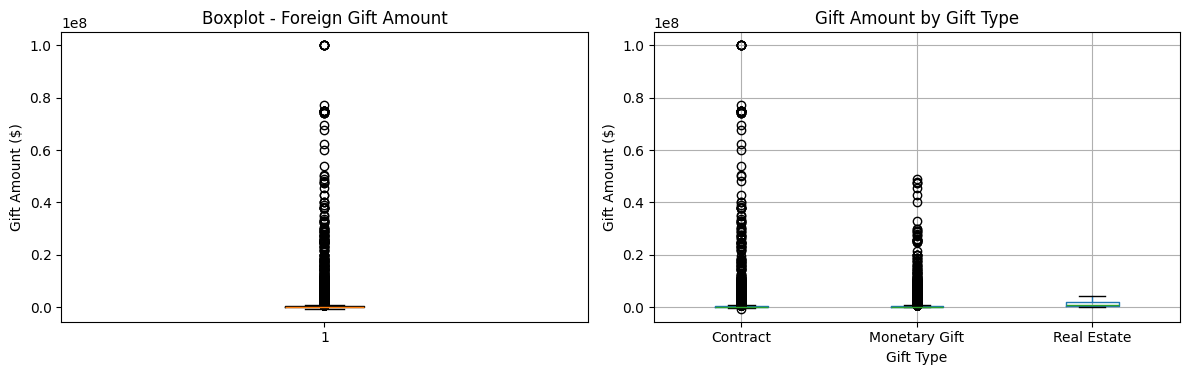

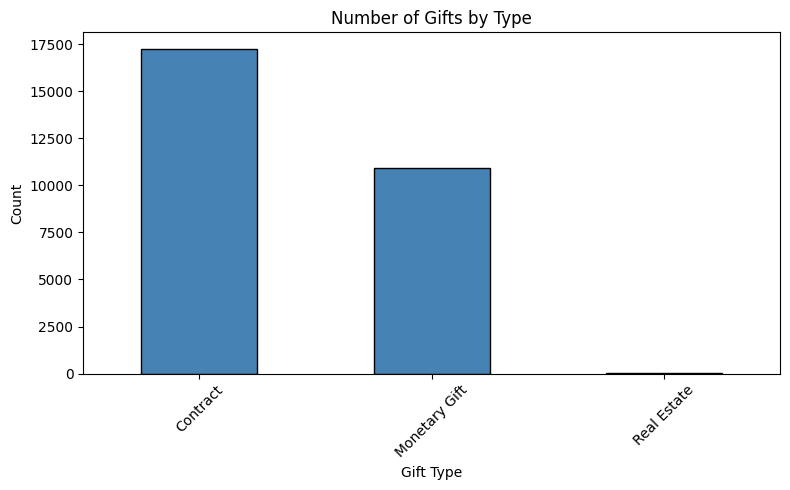


GIFT TYPE PROPORTIONS
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64

Proportion of Contracts: 0.00%
Proportion of Real Estate: 0.04%
Proportion of Monetary: 0.00%


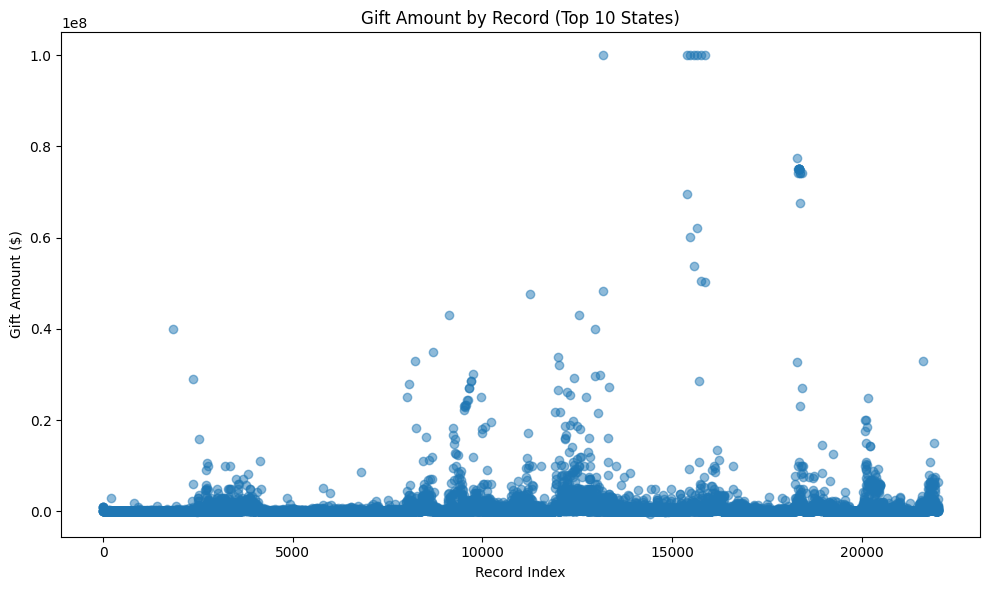

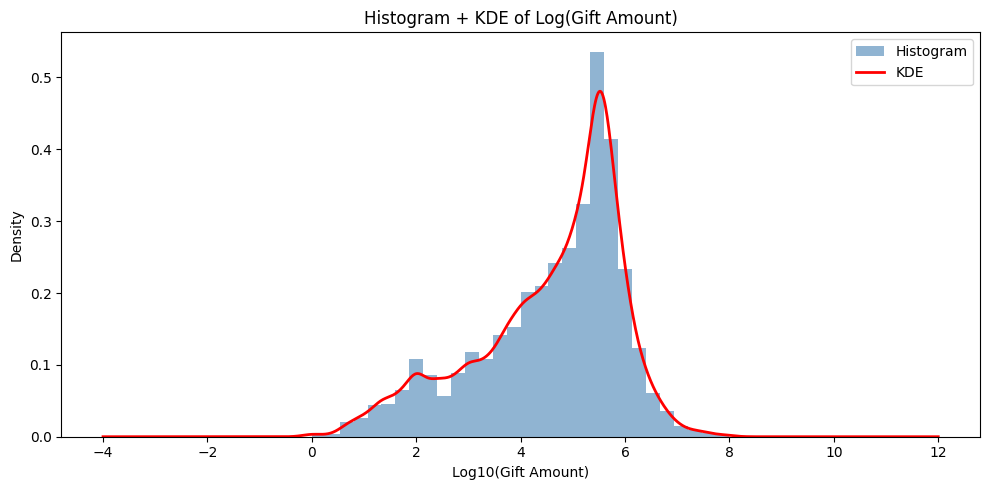

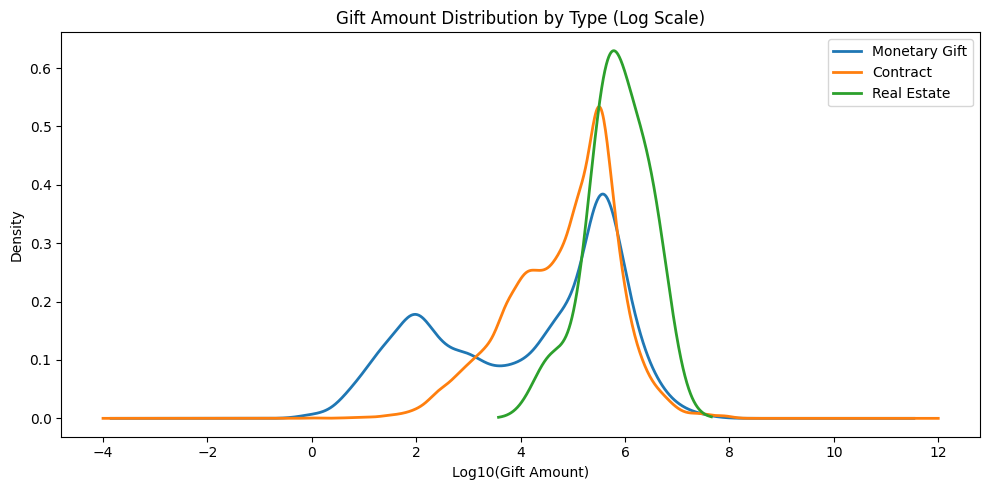

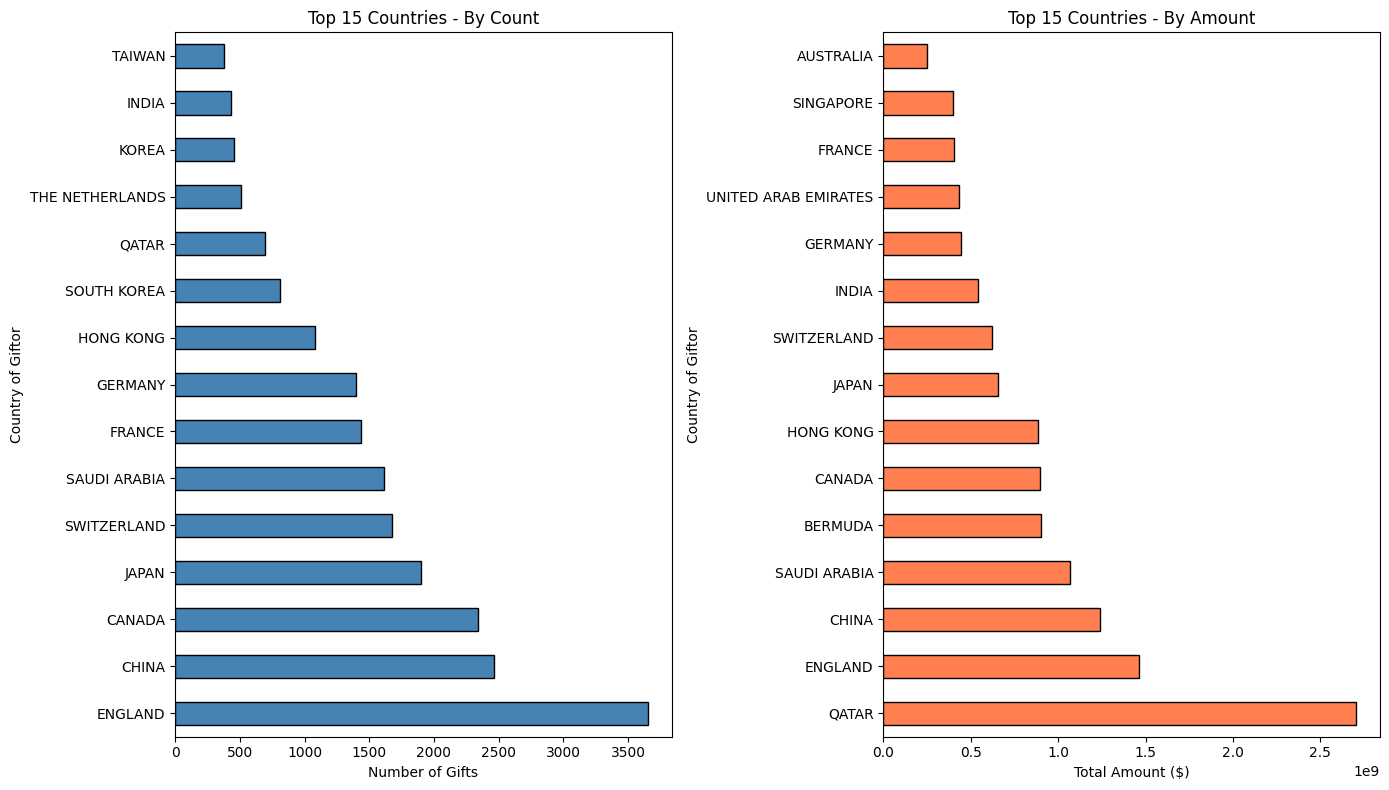


TOP 15 GIFTORS - By Total Amount
Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64


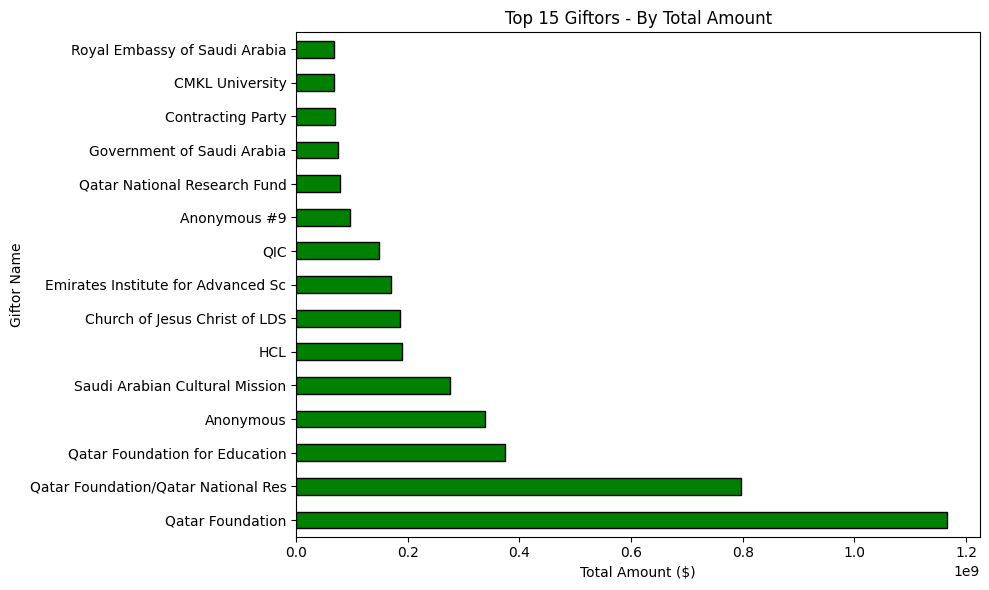


SUMMARY STATISTICS - FOREIGN GIFT AMOUNT
count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64

GIFT TYPE BREAKDOWN
Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

TOP 5 COUNTRIES (by amount)
Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
Name: Foreign Gift Amount, dtype: int64


In [3]:
# Q2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your CSV file
data = pd.read_csv('ForeignGifts_edu.csv')

print("Dataset shape:", data.shape)
print("\nFirst few rows:")
print(data.head())
print("\nColumn names:")
print(data.columns.tolist())
print("\nData types:")
print(data.dtypes)

# HISTOGRAM - Foreign Gift Amount (Raw vs Log Scale)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data['Foreign Gift Amount'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Foreign Gift Amount - Raw Scale (Long Tail)')
axes[0].set_xlabel('Gift Amount ($)')
axes[0].set_ylabel('Frequency')

# Log scale
amount_positive = data[data['Foreign Gift Amount'] > 0]['Foreign Gift Amount']
axes[1].hist(np.log10(amount_positive), bins=50, color='coral', edgecolor='black')
axes[1].set_title('Foreign Gift Amount - Log Scale (Transformed)')
axes[1].set_xlabel('Log10(Gift Amount)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


# BOXPLOT - Gift Amount by Gift Type

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(data['Foreign Gift Amount'])
axes[0].set_ylabel('Gift Amount ($)')
axes[0].set_title('Boxplot - Foreign Gift Amount')

data.boxplot(column='Foreign Gift Amount', by='Gift Type', ax=axes[1])
axes[1].set_ylabel('Gift Amount ($)')
axes[1].set_title('Gift Amount by Gift Type')
plt.suptitle('')
plt.tight_layout()
plt.show()


# BAR CHART - Gift Type Distribution

plt.figure(figsize=(8, 5))
data['Gift Type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Gift Type')
plt.ylabel('Count')
plt.title('Number of Gifts by Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate proportions of each gift type
gift_type_proportions = data['Gift Type'].value_counts(normalize=True)
print("\nGIFT TYPE PROPORTIONS")
print(gift_type_proportions)
print(f"\nProportion of Contracts: {gift_type_proportions.get('Contracts', 0):.2%}")
print(f"Proportion of Real Estate: {gift_type_proportions.get('Real Estate', 0):.2%}")
print(f"Proportion of Monetary: {gift_type_proportions.get('Monetary', 0):.2%}")

# SCATTERPLOT - Amount vs Institution State (top states only)

top_states = data['State'].value_counts().head(10).index
data_top = data[data['State'].isin(top_states)]

plt.figure(figsize=(10, 6))
plt.scatter(range(len(data_top)), data_top['Foreign Gift Amount'], alpha=0.5)
plt.xlabel('Record Index')
plt.ylabel('Gift Amount ($)')
plt.title('Gift Amount by Record (Top 10 States)')
plt.tight_layout()
plt.show()


# HISTOGRAM vs KDE - Foreign Gift Amount (Log Scale)

plt.figure(figsize=(10, 5))

amount_positive = data[data['Foreign Gift Amount'] > 0]['Foreign Gift Amount']
log_amount = np.log10(amount_positive)

plt.hist(log_amount, bins=30, density=True, alpha=0.6, color='steelblue', label='Histogram')
log_amount.plot(kind='kde', linewidth=2, color='red', label='KDE')

plt.xlabel('Log10(Gift Amount)')
plt.ylabel('Density')
plt.title('Histogram + KDE of Log(Gift Amount)')
plt.legend()
plt.tight_layout()
plt.show()


# KDE BY GIFT TYPE

plt.figure(figsize=(10, 5))

for gift_type in data['Gift Type'].unique():
    subset = data[data['Gift Type'] == gift_type]
    amount_pos = subset[subset['Foreign Gift Amount'] > 0]['Foreign Gift Amount']
    if len(amount_pos) > 1:
        np.log10(amount_pos).plot(kind='kde', linewidth=2, label=gift_type)

plt.xlabel('Log10(Gift Amount)')
plt.ylabel('Density')
plt.title('Gift Amount Distribution by Type (Log Scale)')
plt.legend()
plt.tight_layout()
plt.show()


# TOP 10 COUNTRIES - By Number of Gifts

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

top_countries_count = data['Country of Giftor'].value_counts().head(15)
top_countries_count.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Number of Gifts')
axes[0].set_title('Top 15 Countries - By Count')

# By Amount
top_countries_amount = data.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
top_countries_amount.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_xlabel('Total Amount ($)')
axes[1].set_title('Top 15 Countries - By Amount')

plt.tight_layout()
plt.show()

# Top individual giftors by total amount
top_giftors = data.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print("\nTOP 15 GIFTORS - By Total Amount")
print(top_giftors)

plt.figure(figsize=(10, 6))
top_giftors.plot(kind='barh', color='green', edgecolor='black')
plt.xlabel('Total Amount ($)')
plt.title('Top 15 Giftors - By Total Amount')
plt.tight_layout()
plt.show()

# SUMMARY STATISTICS

print("\n" + "SUMMARY STATISTICS - FOREIGN GIFT AMOUNT")
print(data['Foreign Gift Amount'].describe())

print("\n" + "GIFT TYPE BREAKDOWN")
print(data['Gift Type'].value_counts())

print("\n" + "TOP 5 COUNTRIES (by amount)")
print(data.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head())

## Key Findings

The dataset reveals that Contracts are main gift type by frequency (61%),
while Monetary Gifts comprise 39% of all gifts. The total gift amounts show a rightward skew on the visuals, with a median of USD 95K but outliers reaching USD 100M.

By country, Qatar is the largest donor ($2.7 billion total), followed by England and China. This is driven primarily by the Qatar Foundation which collectively represent the largest donors.

The log-scale transformation shows a visual that is easier to interpret, but it is important to note that the dataset contains some negative values. These are most likely corrections for donation ammounts. These negative values only represent a small portion of the data. There is significant geographic concentration of donations. The top 5 countries accounting for ~40% of total gifted amounts.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [4]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]